# Visualize Patch Predictions

For a list of patch IDs, plots satellite / elevation / true crown closure / linear regression estimate / SegFormer estimate side by side, one row per patch. Reads everything directly from the existing repos (no model loading, no inference) -- the two prediction repos (`crown_closure_pred_linear`, `crown_closure_pred_segformer`) are produced by `generate_prediction_mosaics.py`, so run that first if they're not populated yet.

In [54]:
import os
from PIL import Image
import matplotlib.pyplot as plt

SAT_OUT       = '/Volumes/Spleen/CABIN/datasets/patches/satellite_imagery'
DEM_OUT       = '/Volumes/Spleen/CABIN/datasets/patches/elevation'
CANOPY_OUT    = '/Volumes/Spleen/CABIN/datasets/patches/crown_closure'
LINEAR_OUT    = '/Volumes/Spleen/CABIN/datasets/patches/crown_closure_pred_linear'
SEGFORMER_OUT = '/Volumes/Spleen/CABIN/datasets/patches/crown_closure_pred_segformer'
PLOTS_DIR     = '/Volumes/Spleen/CABIN/plots'

os.makedirs(PLOTS_DIR, exist_ok=True)

# (title, repo, cmap, vmin, vmax) -- vmin/vmax fixed explicitly rather
# than left to autoscale, so contrast is comparable patch to patch
# instead of each image being stretched to its own min/max.
COLUMNS = [
    ('Satellite', SAT_OUT, None, None, None),
    ('Elevation', DEM_OUT, 'gray', 0, 255),
    ('Linear Regression', LINEAR_OUT, 'gray', 0, 100),
    ('SegFormer', SEGFORMER_OUT, 'gray', 0, 100),
    ('Base Truth', CANOPY_OUT, 'gray', 0, 100),
]

In [ ]:
import random

def plot_patch_sets(patch_ids=None, n_random=3, save=True):
    """
    patch_ids: list of ints, or None/empty to pick n_random patches
    at random from what's actually available. Plots one row per patch:
    satellite, elevation, true crown closure, linear regression
    estimate, SegFormer estimate. Missing files (e.g. predictions not
    generated yet for that patch) show as a placeholder instead of
    erroring.
    """
    if not patch_ids:
        available = sorted(
            int(f[len('patch_'):-len('.png')])
            for f in os.listdir(SAT_OUT) if f.startswith('patch_') and f.endswith('.png')
        )
        patch_ids = sorted(random.sample(available, min(n_random, len(available))))
        print(f'No patch_ids given -- picked {len(patch_ids)} at random: {patch_ids}')

    n = len(patch_ids)
    fig, axes = plt.subplots(n, len(COLUMNS), figsize=(5 * len(COLUMNS), 5 * n), squeeze=False)

    for row, patch_id in enumerate(patch_ids):
        filename = f'patch_{patch_id:04d}.png'
        for col, (title, repo, cmap, vmin, vmax) in enumerate(COLUMNS):
            ax = axes[row, col]
            img_path = os.path.join(repo, filename)
            if os.path.exists(img_path):
                kwargs = {'cmap': cmap, 'vmin': vmin, 'vmax': vmax} if cmap else {}
                ax.imshow(Image.open(img_path), **kwargs)
            else:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes, fontsize=18, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(title, fontsize=32, fontweight='bold', pad=14)
            if col == 0:
                ax.set_ylabel(f'patch {patch_id}', fontsize=32, fontweight='bold')

    fig.suptitle('Comparing Crown Closure Estimations: Linear Regression vs. SegFormer', fontsize=40, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save:
        # Fixed filename -- always overwrites rather than accumulating
        # a new file per run/patch selection.
        path = os.path.join(PLOTS_DIR, 'patch_predictions.png')
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f'Saved -> {path}')
    plt.show()

No patch_ids given -- picked 3 at random: [1008, 1803, 2124]
Saved -> /Volumes/Spleen/CABIN/plots/patch_predictions.png


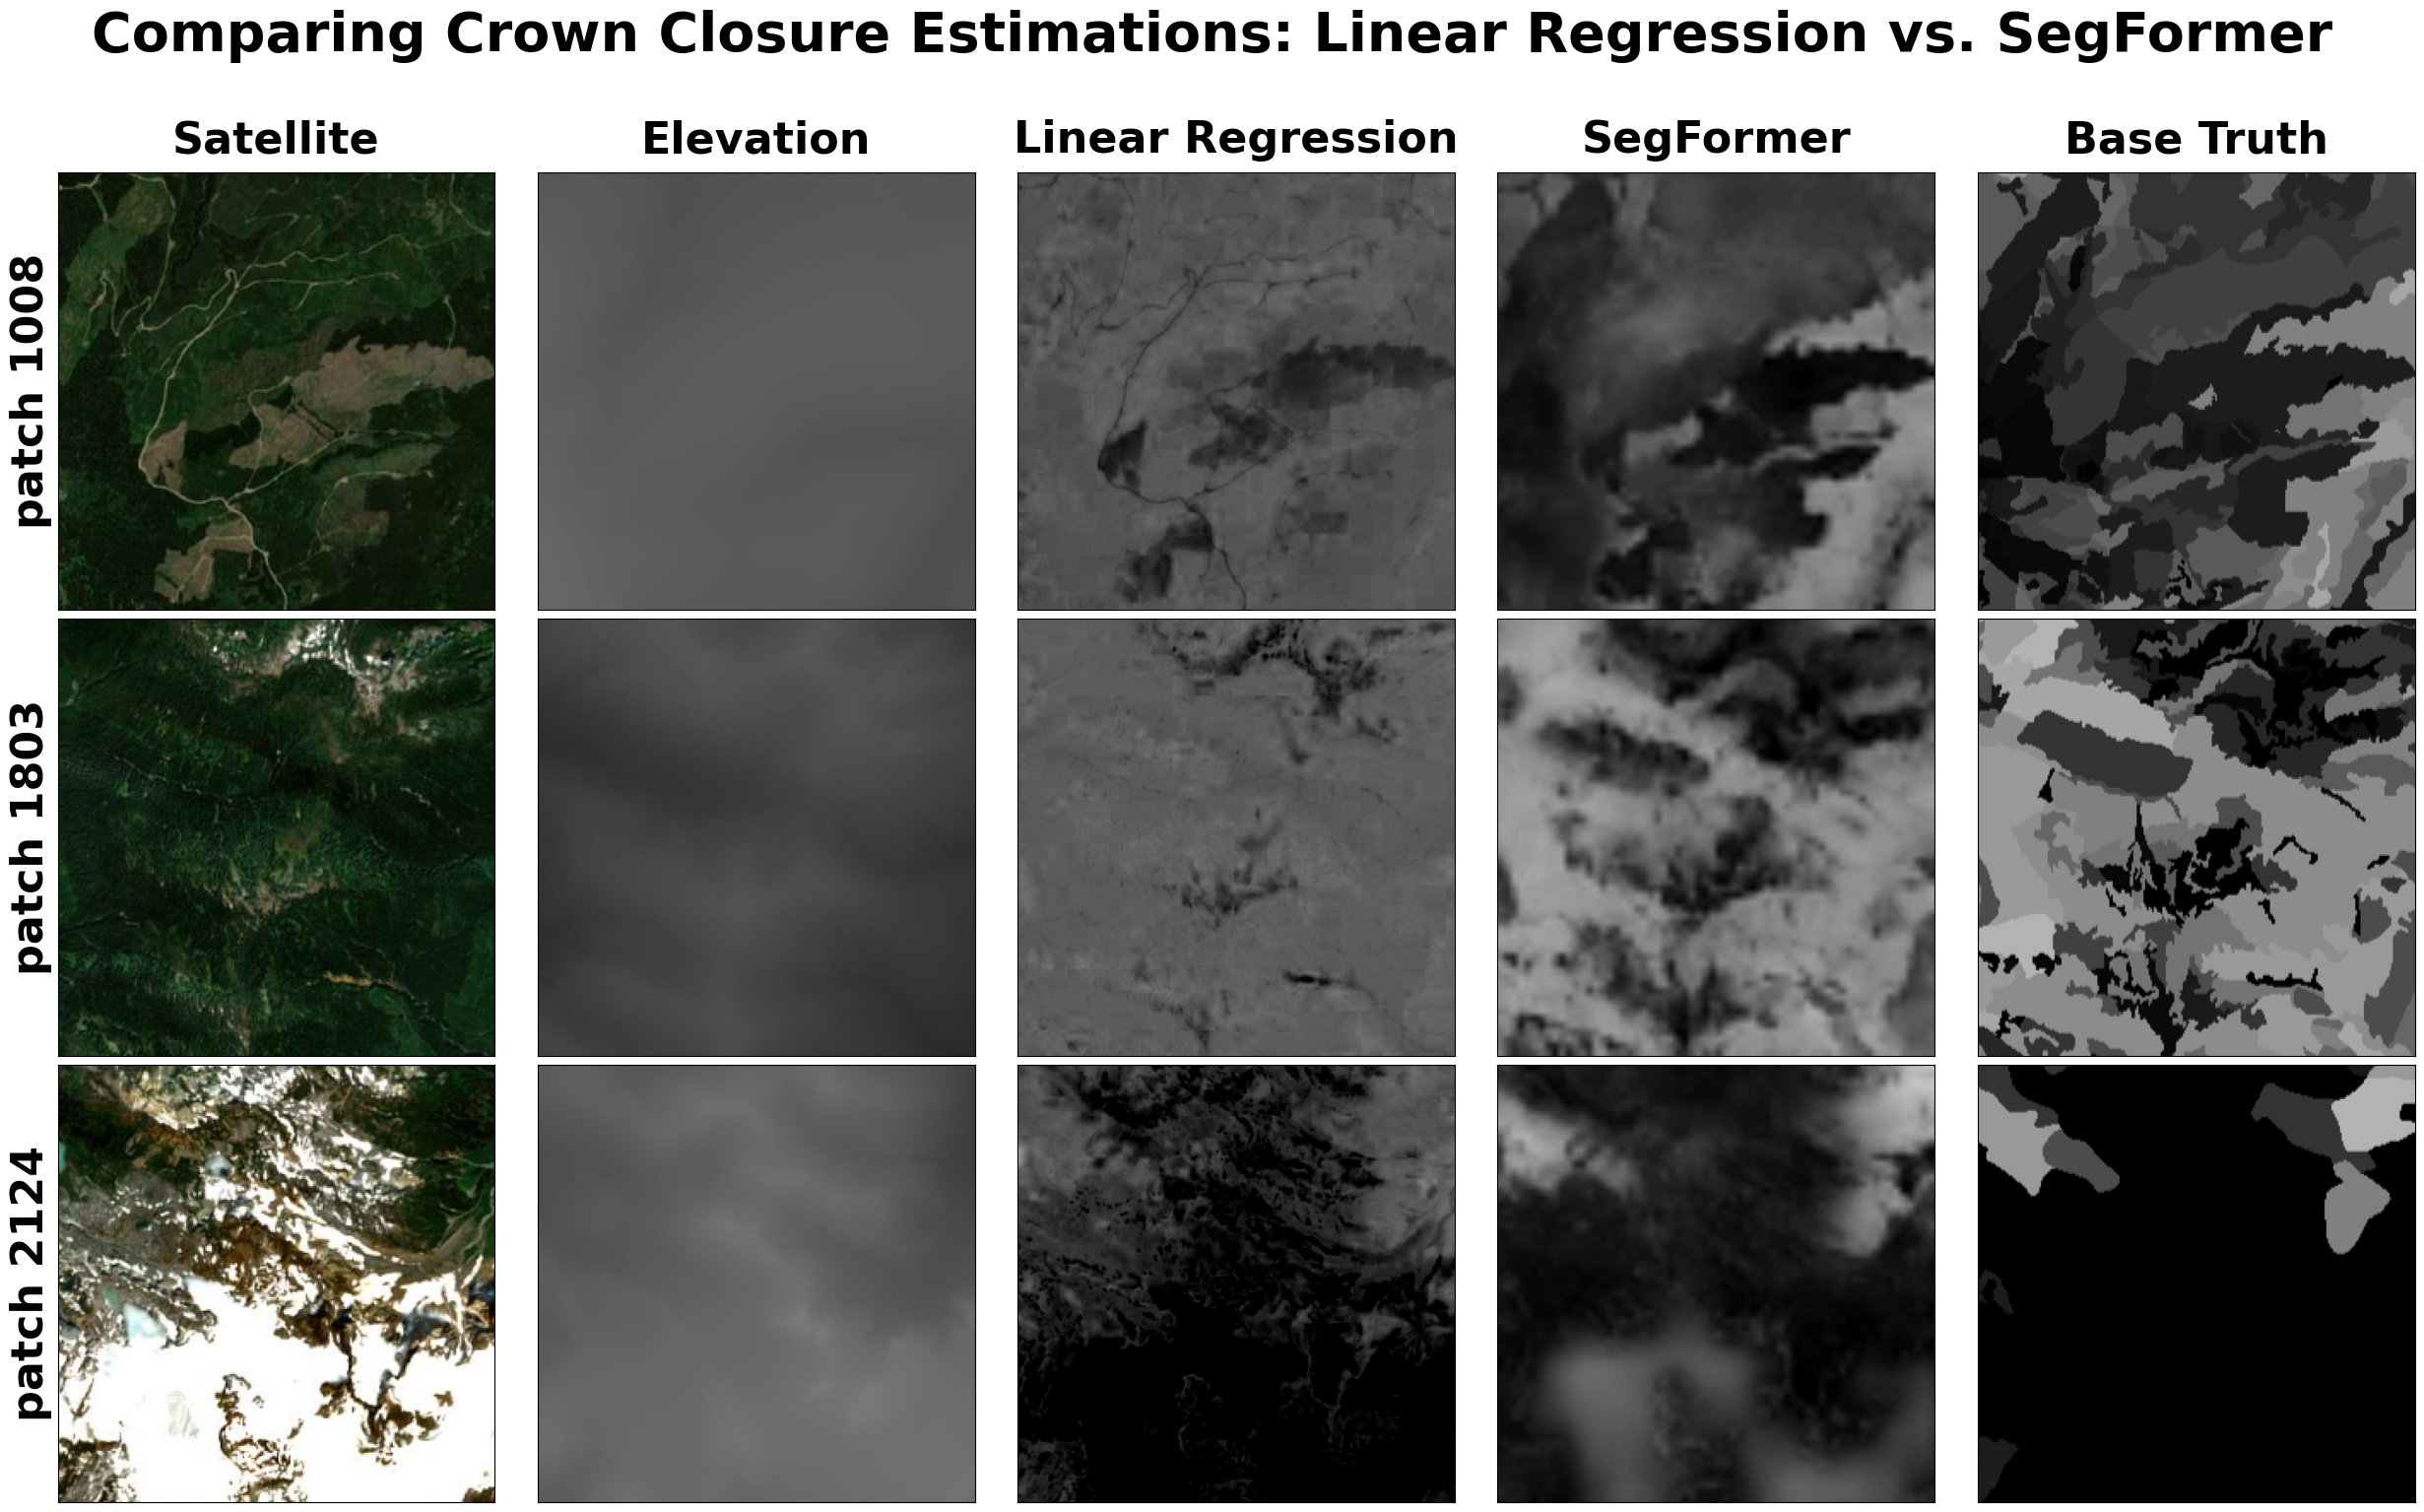

In [58]:
# Set specific IDs, e.g. PATCH_IDS = [0, 100, 500, 1000, 2000], or
# leave as None to pick random ones instead.
PATCH_IDS = None

plot_patch_sets(PATCH_IDS)